# 07 Similarity Analysis

## Purpose

This notebook compares glycan sequence embeddings from one saved masked-language-model checkpoint.

## Inputs

- one saved `best_model/` folder in `MyDrive/ProjectRoot/checkpoints/`
- user-specified glycan sequences and sequence pairs

## Outputs

- pairwise cosine similarity tables
- tokenization preview tables
- sequence similarity matrices
- similarity heatmaps
- config JSON files for reproducibility

## Notes to myself

The code stays in GitHub and the large artifacts stay in Drive. This notebook is meant to be the simple path: point at one trained model, compare a few glycans, and save the results.


## Setup note

Same split as the rest of the project.

- code and notebooks stay in GitHub
- checkpoints and generated similarity outputs stay in Drive
- Colab pulls the repo at the start
- this notebook writes results back into `MyDrive/ProjectRoot/results/similarity/`


In [13]:
# ==============================================================================
# 0. SET UP THE COLAB ENVIRONMENT
# ==============================================================================
import os
import sys

from google.colab import drive

# Mount Drive first so the notebook can read model checkpoints and write
# outputs back into the shared GlycanProject folder.
drive.mount('/content/drive')

GITHUB_OWNER = 'hb791-dev'
REPO_NAME = 'glycan-roberta'
REPO_URL = f'https://github.com/{GITHUB_OWNER}/{REPO_NAME}.git'
REPO_DIR = f'/content/{REPO_NAME}'

# Pull the latest repo state into Colab so the notebook uses the current
# version of the project code stored on GitHub.
if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    !git clone -q {REPO_URL} {REPO_DIR}
else:
    print('Repository already exists. Pulling latest changes...')

%cd {REPO_DIR}
!git pull origin main --no-edit -q

# Add the repo root to the Python path so notebook cells can import helper
# modules directly from src/.
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print('Colab environment ready.')
print(f'Repo directory: {REPO_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository already exists. Pulling latest changes...
/content/glycan-roberta
Colab environment ready.
Repo directory: /content/glycan-roberta


In [14]:
# ==============================================================================
# 1. IMPORT ANALYSIS TOOLS
# ==============================================================================
from pathlib import Path

from IPython.display import display

# src/similarity.py now holds both the core embedding utilities and the
# higher-level analysis helpers used by this notebook.
from src.similarity import (
    load_similarity_artifacts,
    run_similarity_analysis,
    validate_similarity_inputs,
)


In [15]:
# ==============================================================================
# 2. DEFINE DRIVE PATHS
# ==============================================================================
# Keep one explicit Drive root so every downstream path is easy to inspect and
# easy to update if the project folder ever moves.
DRIVE_ROOT = Path('/content/drive/MyDrive/ProjectRoot')
SIMILARITY_RESULTS_DIR = DRIVE_ROOT / 'results' / 'similarity'

# Create the shared similarity-results folder once. Each notebook run writes
# into a named subfolder beneath this root.
SIMILARITY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Drive root: {DRIVE_ROOT}')
print(f'Similarity results root: {SIMILARITY_RESULTS_DIR}')


Drive root: /content/drive/MyDrive/ProjectRoot
Similarity results root: /content/drive/MyDrive/ProjectRoot/results/similarity


In [16]:
# ==============================================================================
# 3. CHOOSE ONE MODEL
# ==============================================================================
# Update only MODEL_DIR when you want to analyze a different checkpoint. The
# notebook derives the output folder name automatically from this path.
MODEL_DIR = DRIVE_ROOT / 'checkpoints' / 'manual' / 'mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20' / 'best_model'

if 'replace_with_experiment_name' in str(MODEL_DIR):
    raise ValueError('Set MODEL_DIR to one real best_model folder before running this notebook.')

# Expect the standard project checkpoint layout:
# ... / checkpoints / <tokenizer_family> / <experiment_name> / best_model
if MODEL_DIR.name != 'best_model':
    raise ValueError('MODEL_DIR should point directly to a best_model folder.')

TOKENIZER_FAMILY = MODEL_DIR.parent.parent.name
EXPERIMENT_NAME = MODEL_DIR.parent.name
OUTPUT_NAME = f"{TOKENIZER_FAMILY}__{EXPERIMENT_NAME}"
OUTPUT_DIR = SIMILARITY_RESULTS_DIR / OUTPUT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model directory: {MODEL_DIR}')
print(f'Tokenizer family: {TOKENIZER_FAMILY}')
print(f'Experiment name: {EXPERIMENT_NAME}')
print(f'Output directory: {OUTPUT_DIR}')


Model directory: /content/drive/MyDrive/ProjectRoot/checkpoints/manual/mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/best_model
Tokenizer family: manual
Experiment name: mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20
Output directory: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20


## Choose glycans

This is the main analysis configuration cell. The model is already chosen above, so this cell only controls which glycans get compared.


In [17]:
# ==============================================================================
# 4. CONFIGURE GLYCANS TO ANALYZE
# ==============================================================================
# SEQUENCE_PAIRS is used for direct side-by-side cosine similarity checks.
# Give each pair a short descriptive name so the exported CSV is easy to read.
SEQUENCE_PAIRS = [
    {
        'pair_name': 'linkage_swap',
        'seq1': 'Gal(b1-4)GlcNAc',
        'seq2': 'Gal(b1-3)GlcNAc',
    },
    {
        'pair_name': 'terminal_sialylation',
        'seq1': 'Neu5Ac(a2-3)Gal(b1-4)GlcNAc',
        'seq2': 'Gal(b1-4)GlcNAc',
    },
]

# MATRIX_SEQUENCES is used for the full pairwise similarity matrix and the
# heatmap. Include every sequence you want compared against every other one.
MATRIX_SEQUENCES = [
    'Gal(b1-4)GlcNAc',
    'Gal(b1-3)GlcNAc',
    'Neu5Ac(a2-3)Gal(b1-4)GlcNAc',
    'Fuc(a1-2)Gal(b1-4)GlcNAc',
]

# Leave MAX_LENGTH as None to use the tokenizer's configured maximum length.
# BATCH_SIZE controls embedding throughput for the matrix calculation.
MAX_LENGTH = None
BATCH_SIZE = 32

print(f'Sequence pairs configured: {len(SEQUENCE_PAIRS)}')
print(f'Matrix sequences configured: {len(MATRIX_SEQUENCES)}')


Sequence pairs configured: 2
Matrix sequences configured: 4


In [18]:
# ==============================================================================
# 5. VALIDATE INPUTS
# ==============================================================================
# Delegate validation to src/ so the same checks can be reused anywhere this
# similarity workflow is run.
validate_similarity_inputs(
    model_dir=MODEL_DIR,
    sequence_pairs=SEQUENCE_PAIRS,
    matrix_sequences=MATRIX_SEQUENCES,
    output_dir=OUTPUT_DIR,
)

print('Inputs look good.')


Inputs look good.


Loading model from: /content/drive/MyDrive/ProjectRoot/checkpoints/manual/mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/best_model


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

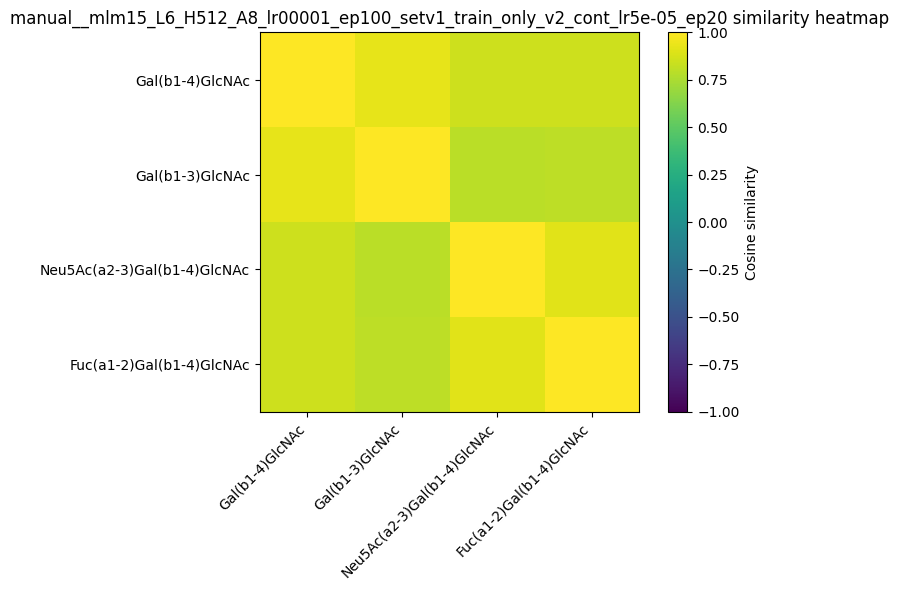

Pairwise comparison results


,pair_name,seq1,seq2,cosine_similarity,seq1_tokens,seq2_tokens
0,linkage_swap,Gal(b1-4)GlcNAc,Gal(b1-3)GlcNAc,0.924799,Gal | ( | b1-4 | ) | GlcNAc,Gal | ( | b1-3 | ) | GlcNAc
1,terminal_sialylation,Neu5Ac(a2-3)Gal(b1-4)GlcNAc,Gal(b1-4)GlcNAc,0.848647,<unk> | ( | a2-3 | ) | Gal | ( | b1-4 | ) | Gl...,Gal | ( | b1-4 | ) | GlcNAc


Tokenization preview


,sequence,tokens,token_count
0,Gal(b1-4)GlcNAc,Gal | ( | b1-4 | ) | GlcNAc,5
1,Gal(b1-3)GlcNAc,Gal | ( | b1-3 | ) | GlcNAc,5
2,Neu5Ac(a2-3)Gal(b1-4)GlcNAc,<unk> | ( | a2-3 | ) | Gal | ( | b1-4 | ) | Gl...,9
3,Fuc(a1-2)Gal(b1-4)GlcNAc,Fuc | ( | a1-2 | ) | Gal | ( | b1-4 | ) | GlcNAc,9


Similarity matrix


,Gal(b1-4)GlcNAc,Gal(b1-3)GlcNAc,Neu5Ac(a2-3)Gal(b1-4)GlcNAc,Fuc(a1-2)Gal(b1-4)GlcNAc
Gal(b1-4)GlcNAc,1.000000,0.924799,0.848647,0.849408
Gal(b1-3)GlcNAc,0.924799,1.000000,0.790154,0.801387
Neu5Ac(a2-3)Gal(b1-4)GlcNAc,0.848647,0.790154,1.000000,0.911931
Fuc(a1-2)Gal(b1-4)GlcNAc,0.849408,0.801387,0.911931,1.000000


Saved outputs to: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20
Pair results: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/similarity_pairs.csv
Tokenization preview: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/tokenization_preview.csv
Similarity matrix: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/similarity_matrix.csv
Heatmap saved to: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/similarity_heatmap.png
Config saved to: /content/drive/MyDrive/ProjectRoot/results/similarity/manual__mlm15_L6_H512_A8_lr00001_ep100_setv1_train_only_v2_cont_lr5e-05_ep20/similarity_conf

In [19]:
# ==============================================================================
# 6. RUN THE SIMILARITY ANALYSIS AND SAVE OUTPUTS TO DRIVE
# ==============================================================================
# Load the selected checkpoint once, then pass it into the higher-level src
# helper that computes tables, draws the heatmap, and saves outputs.
print(f'Loading model from: {MODEL_DIR}')
tokenizer, model, device = load_similarity_artifacts(str(MODEL_DIR))

results = run_similarity_analysis(
    tokenizer=tokenizer,
    model=model,
    sequence_pairs=SEQUENCE_PAIRS,
    matrix_sequences=MATRIX_SEQUENCES,
    output_dir=OUTPUT_DIR,
    output_name=OUTPUT_NAME,
    device=device,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    model_dir=MODEL_DIR,
)

# The returned dataframes are still displayed inline here so the notebook
# remains easy to inspect interactively.
print('Pairwise comparison results')
display(results['pair_results_df'])

print('Tokenization preview')
display(results['tokenization_preview_df'])

print('Similarity matrix')
display(results['similarity_df'])

# src/run_similarity_analysis already saved the CSVs, JSON config, and
# heatmap image. Print the saved paths here for quick reference.
saved_paths = results['saved_paths']
print(f'Saved outputs to: {OUTPUT_DIR}')
print(f"Pair results: {saved_paths['pair_results_path']}")
print(f"Tokenization preview: {saved_paths['tokenization_preview_path']}")
print(f"Similarity matrix: {saved_paths['similarity_matrix_path']}")
print(f"Heatmap saved to: {saved_paths['heatmap_path']}")
print(f"Config saved to: {saved_paths['config_path']}")
